# Total pop calc

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

In [3]:
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
adm0 = gpd.read_file(url)

In [4]:
blob_name = "worldpop/pop_count/global_pop_2026_CN_1km_R2025A_UA_v1.tif"
da_wp_global = stratus.open_blob_cog(blob_name, container_name="raster")

/Users/tdowning/OCHA/repos/ds-storm-impact-harmonisation/.venv/lib/python3.11/site-packages/rioxarray/_io.py:939: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


In [7]:
da_wp_global = da_wp_global.squeeze(drop=True)

<Axes: >

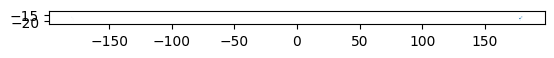

In [6]:
adm0[adm0["ADM0_A3"] == "FJI"].plot()

In [9]:
da_wp_adm = da_wp_global.rio.clip(adm0[adm0["ADM0_A3"] == "FJI"].geometry).compute()

In [12]:
da_wp_adm.where(da_wp_adm > 0).sum()

<xarray.DataArray ()> Size: 4B
array(832039.06, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     -99999.0

In [13]:
dicts = []

for iso3, row in tqdm(adm0.set_index("ADM0_A3").iterrows(), total=len(adm0)):
    _da_wp_adm = da_wp_global.rio.clip([row.geometry]).compute()
    try:
        pop = int(_da_wp_adm.where(_da_wp_adm > 0).sum())
    except Exception as e:
        print(iso3)
        print(e)
        pop = 0
    dicts.append({"ADM0_A3": iso3, "total_pop": pop})
        

 60%|████████████████████████████████████████████████████████████████████████████████████████▉                                                            | 154/258 [2:13:34<1:30:12, 52.04s/it]


RasterioIOError: Read failed. See previous exception for details.